In [1]:
include("../RayTracing.jl")

Main.RayTracing

In [91]:
function inner_loop(i::UInt32, p::UInt32, w::UInt32)::UInt32
    i ⊻= p
    i *= 0xe170893d
    i ⊻= p >> 16
    i ⊻= (i & w) >> 4
    i ⊻= p >> 8
    i *= 0x0929eb3f
    i ⊻= p >> 23
    i ⊻= (i & w) >> 1
    i *= UInt32(1) | (p >> 27) # careful on casting here. need not worry on bit shifts
    i *= 0x6935fa69
    i ⊻= (i & w) >> 11
    i *= 0x74dcb303
    i ⊻= (i & w) >> 2
    i *= 0x9e501cc3
    i ⊻= (i & w) >> 2
    i *= 0xc860a3df
    i &= w
    i ⊻= i >> 5
    return i
end

function PermutationElement(i::UInt32, l::UInt32, p::Union{UInt, Int})::Int32
    p = UInt32(p & typemax(UInt32)) # PBRT's hash is a uint64_t and PermutationElement does the truncation. we have to do it explicitly.
    w = l - UInt32(1) # careful on casting
    w |= w >> 1
    w |= w >> 2
    w |= w >> 4
    w |= w >> 8
    w |= w >> 16
    i = inner_loop(i, p, w) # We don't have a do-while only while-do
    while i >= l
        i = inner_loop(i, p, w)
    end
    return (i + p) % l
end

PermutationElement (generic function with 2 methods)

# First check PermutationElement

In [84]:
hash = rand(Int64)
hash = 4032212079371261838

4032212079371261838

In [88]:
@assert stratum = PermutationElement(UInt32(0), UInt32(36), 400) == 26
@assert stratum = PermutationElement(UInt32(0), UInt32(36), 4032212079371261838) == 15

# Second check Get1D() w/o jitter

In [2]:
using Plots

In [3]:
RayTracing.Random.seed!(1234)

Random.TaskLocalRNG()

In [62]:
samples_per_pixel = 36
jitter = false
dimension = 0
d = Int(trunc(sqrt(samples_per_pixel)))
while samples_per_pixel % d != 0
    d -= 1
end
x_pixel_samples = samples_per_pixel / d
y_pixel_samples = samples_per_pixel / x_pixel_samples

6.0

In [89]:
hash = rand(Int64)
hash = 4032212079371261838 # <-- works
hash = 0x123456789abcdef

0x0123456789abcdef

In [92]:
X = zeros(Float64, samples_per_pixel)
Y = zeros(Float64, samples_per_pixel)
for sample_index in 0:(samples_per_pixel-1)
    stratum = PermutationElement(UInt32(sample_index), UInt32(36), hash)
    # print("$(stratum)\n")
    x = stratum % x_pixel_samples
    y = stratum ÷ x_pixel_samples
    # print("($(x),$(y))\n")
    dx = jitter ? rand() : Float32(0.5)
    dy = jitter ? rand() : Float32(0.5)
    X[sample_index+1] = (x+dx)/x_pixel_samples
    Y[sample_index+1] = (y+dy)/y_pixel_samples
    # print("$((x+dx)/x_pixel_samples):$((y+dy)/y_pixel_samples)\n\n")
end

9
(3.0,1.0)
0.5833333333333334:0.25

33
(3.0,5.0)
0.5833333333333334:0.9166666666666666

30
(0.0,5.0)
0.08333333333333333:0.9166666666666666

15
(3.0,2.0)
0.5833333333333334:0.4166666666666667

26
(2.0,4.0)
0.4166666666666667:0.75

17
(5.0,2.0)
0.9166666666666666:0.4166666666666667

27
(3.0,4.0)
0.5833333333333334:0.75

7
(1.0,1.0)
0.25:0.25

28
(4.0,4.0)
0.75:0.75

1
(1.0,0.0)
0.25:0.08333333333333333

10
(4.0,1.0)
0.75:0.25

22
(4.0,3.0)
0.75:0.5833333333333334

5
(5.0,0.0)
0.9166666666666666:0.08333333333333333

25
(1.0,4.0)
0.25:0.75

11
(5.0,1.0)
0.9166666666666666:0.25

21
(3.0,3.0)
0.5833333333333334:0.5833333333333334

16
(4.0,2.0)
0.75:0.4166666666666667

23
(5.0,3.0)
0.9166666666666666:0.5833333333333334

35
(5.0,5.0)
0.9166666666666666:0.9166666666666666

14
(2.0,2.0)
0.4166666666666667:0.4166666666666667

29
(5.0,4.0)
0.9166666666666666:0.75

18
(0.0,3.0)
0.08333333333333333:0.5833333333333334

12
(0.0,2.0)
0.08333333333333333:0.4166666666666667

6
(0.0,1.0)
0.0833333333333

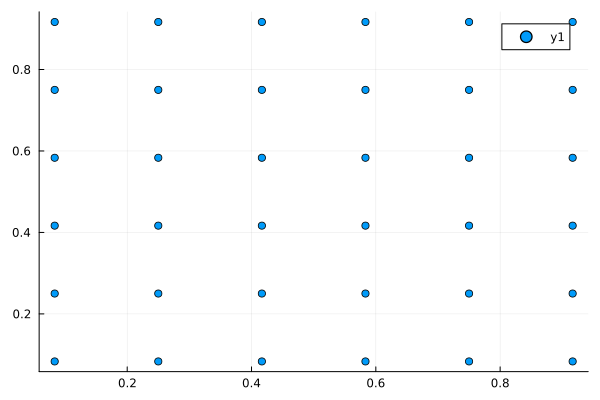

In [83]:
plot(X, Y, seriestype=:scatter)

In [ ]:
# /******************************************************************************

#                               Online C++ Compiler.
#                Code, Compile, Run and Debug C++ program online.
# Write your code in this editor and press "Run" button to compile and execute it.

# *******************************************************************************/

# #include <iostream>
# using namespace std;

# inline int PermutationElement(uint32_t i, uint32_t l, uint32_t p) {
#     uint32_t w = l - 1;
#     w |= w >> 1;
#     w |= w >> 2;
#     w |= w >> 4;
#     w |= w >> 8;
#     w |= w >> 16;
#     do {
#         i ^= p;
#         i *= 0xe170893d;
#         i ^= p >> 16;
#         i ^= (i & w) >> 4;
#         i ^= p >> 8;
#         i *= 0x0929eb3f;
#         i ^= p >> 23;
#         i ^= (i & w) >> 1;
#         i *= 1 | p >> 27;
#         i *= 0x6935fa69;
#         i ^= (i & w) >> 11;
#         i *= 0x74dcb303;
#         i ^= (i & w) >> 2;
#         i *= 0x9e501cc3;
#         i ^= (i & w) >> 2;
#         i *= 0xc860a3df;
#         i &= w;
#         i ^= i >> 5;
#     } while (i >= l);
#     return (i + p) % l;
# }

# int main()
# {
#     uint32_t l = 36;
#     uint64_t p = 4032212079371261838;
#     for (int i = 0; i < 36; i++){
#         cout << PermutationElement(i, l, p) << "\n";
#         int stratum = PermutationElement(i, l, p);
#         int x = stratum % 6;
#         int y = stratum / 6;
#         cout << "(" << x << "," << y << ")\n";
#         float dx = 0.5f;
#         float dy = 0.5f;
#         cout << (x+dx)/6 << ":" << (y+dy)/6 << "\n\n";
#     }
    

#     return 0;
# }
